# 12 — Robustness

A learned reflex, the worlds it was not trained in, and domain
randomisation · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/12-robustness/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

Nothing here trains: the policies were trained for 16 minutes each on a
36-core machine and are downloaded. Evaluating them takes a few minutes.

## Last week’s planner, and its bill

MPPI stood through a 300 N shove — and paid 100 ms of computing for
every 40 ms of robot time, with a perfect model of the world.

A **policy** pays once, in training, and then answers in a tenth of a
millisecond. Today:

1.  Train one to take a shove (PPO, weeks 8–10, done right).
2.  Measure what it learned — and the worlds where it did not.
3.  Randomise the world during training, and measure again.

The question changes from *“can it learn?”* to *“what did it learn to
depend on?”*

**Layer 5**, and the sim-to-real gap, measured without leaving
simulation.

------------------------------------------------------------------------

## Setting up

In [1]:
import importlib.util

# On Colab, upgrade before importing: pip cannot replace a loaded module.
if importlib.util.find_spec("google.colab") is not None:
    %pip install -q --upgrade "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"

import time, warnings
import numpy as np
import matplotlib.pyplot as plt
import soc4180          # first: it selects the GL backend before mujoco loads
import mujoco
from pathlib import Path
from stable_baselines3 import PPO
from soc4180 import checkpoints
from soc4180.envs import G1PushEnv
warnings.filterwarnings("ignore")

BASE = "https://raw.githubusercontent.com/gnoejh/soc4180/main/weeks/12-robustness/checkpoints/"
def checkpoint(name):
    """The shipped file beside this notebook, or the same file from GitHub (Colab)."""
    local = Path("checkpoints") / name
    return local if local.exists() else checkpoints.download(name, BASE + name)

policies = {n: PPO.load(checkpoint(f"push_{n}.zip"), device="cpu") for n in ("nominal", "random")}
env = G1PushEnv()
print(f"G1PushEnv: obs {env.observation_space.shape[0]}, action {env.action_space.shape[0]}, "
      f"{1 / env.control_dt:.0f} Hz, {env.max_steps} decisions = {env.max_steps * env.control_dt:.0f} s per episode")

G1PushEnv: obs 42, action 12, 50 Hz, 250 decisions = 5 s per episode

------------------------------------------------------------------------

## The task: take a shove

`G1PushEnv` is week 7’s `G1WalkEnv` with the target velocity at zero,
plus:

- once per 5-second episode, a **shove**: a random size up to 200 N, a
  random horizontal direction, 0.2 s long, at a random moment between 1
  and 3 s;
- a **world** drawn per episode: friction, extra torso mass, servo
  stiffness.

|                       | nominal world | randomised world (`RANDOM_WORLD`)   |
|-----------------------|---------------|-------------------------------------|
| friction scale        | 1.0           | 0.3 … 1.2                           |
| torso mass            | +0 kg         | −5 … +10 kg                         |
| servo stiffness $k_p$ | ×1.0          | ×0.7 … ×1.3 (damping kept critical) |

Same 42 observations, same 12 leg residuals at 50 Hz, same five reward
terms as weeks 7–9. The policy does not see the world it is in, and does
not see the shove coming.

------------------------------------------------------------------------

## Training: week 8’s lesson, applied

``` python
agent = PPO("MlpPolicy", SubprocVecEnv([make(i) for i in range(16)]),
            n_steps=256, batch_size=1024, n_epochs=5, learning_rate=3e-4, gamma=0.99,
            policy_kwargs=dict(log_std_init=-2.0, net_arch=[128, 128]))
agent.learn(total_timesteps=3_000_000)
```

- **`log_std_init = -2`**: week 8 measured that PPO’s default noise (std
  1.0) makes the *sampled* robot fall before anything interesting
  happens. At std 0.135 the sampled robot stands until the shove
  arrives.
- **16 processes**: week 10’s `SubprocVecEnv`, one environment per core.
- **3 million steps**: 16 minutes on 36 cores — 17 hours of simulated
  standing and being shoved, about 17,000 episodes.

Two policies, identical except for the world they trained in: `nominal`
and `random`. `robust.py --train` reproduces either.

------------------------------------------------------------------------

## What the learning curve says

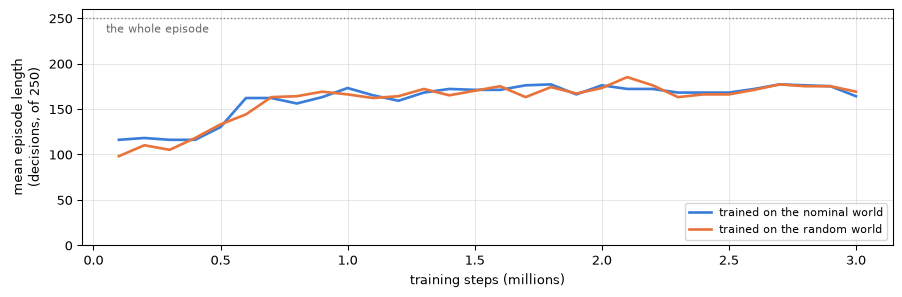

In [2]:
fig, ax = plt.subplots(figsize=(9.5, 3.2))
for name, c in (("nominal", "#3b7dd8"), ("random", "#e8743b")):
    d = np.loadtxt(checkpoint(f"push_{name}.csv"), delimiter=",", skiprows=1)
    ax.plot(d[:, 0] / 1e6, d[:, 2], color=c, lw=2, label=f"trained on the {name} world")
ax.axhline(250, color="0.5", ls=":", lw=1); ax.text(0.05, 244, "the whole episode", fontsize=8, color="0.4", va="top")
ax.set_xlabel("training steps (millions)"); ax.set_ylabel("mean episode length\n(decisions, of 250)")
ax.set_ylim(0, 260); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

It climbs for the first 0.7 million steps and then flattens around 170
of 250. That is not a failure: pushes go up to **200 N**, and no stance
of this robot survives 200 N (MPPI survived it by *stepping* 3 m). The
plateau is the fraction of shoves that can be survived without walking
away.

Week 10’s reading of a curve: *flat is the task’s ceiling, not the
optimiser’s.*

------------------------------------------------------------------------

## Measuring a policy honestly

Training returns are averages over random pushes, random worlds and
noisy actions. To measure, fix everything and count:

In [3]:
def survived(policy, world, push, episodes=10, seed=0):
    """Episodes out of `episodes` still standing after a sideways shove of exactly `push` N."""
    env.world = {k: (v, v) for k, v in world.items()}
    ok = 0
    for k in range(episodes):
        obs, _ = env.reset(seed=seed + k)            # a different crouch and push moment each time
        env.push_force = np.array([0.0, float(push)])     # from the right, exactly `push` newtons
        while True:
            a = np.zeros(12, np.float32) if policy is None else policy.predict(obs, deterministic=True)[0]
            obs, _, terminated, truncated, _ = env.step(a)
            if terminated or truncated:
                break
        ok += not terminated
    return ok

PUSHES = (60, 80, 100, 120)
rows = {"hold the crouch": None, "PPO, nominal world": policies["nominal"], "PPO, randomised world": policies["random"]}
t0 = time.time()
NOMINAL = dict(friction=1.0, mass=0.0, kp=1.0)
table = {name: [survived(p, NOMINAL, f) for f in PUSHES] for name, p in rows.items()}
print(f"episodes survived of 10, nominal world ({time.time() - t0:.0f} s):")
print(f"{'':24s}" + "".join(f"{f:>7} N" for f in PUSHES))
for name, counts in table.items():
    print(f"{name:24s}" + "".join(f"{c:9d}" for c in counts))

episodes survived of 10, nominal world (31 s):
                             60 N     80 N    100 N    120 N
hold the crouch                10        0        0        0
PPO, nominal world             10       10        0        0
PPO, randomised world          10       10        9        1

Deterministic policy (the mean action), sideways shoves as in weeks 7
and 11, ten episodes per cell differing in the moment of the push and
the small random crouch they start from.

------------------------------------------------------------------------

## What it learned

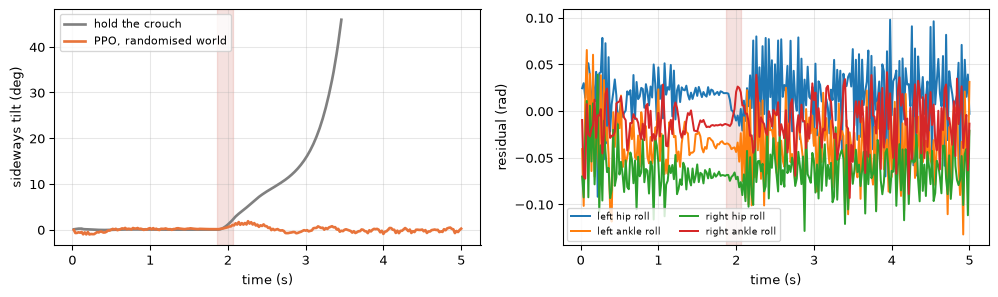

In [4]:
def trace(policy, push=80.0, seed=3):
    env.world = {k: (v, v) for k, v in NOMINAL.items()}
    obs, _ = env.reset(seed=seed); env.push_force = np.array([0.0, push]); out = []
    while True:
        a = np.zeros(12, np.float32) if policy is None else policy.predict(obs, deterministic=True)[0]
        obs, _, term, trunc, _ = env.step(a)
        out.append((env.data.time, env.data.qpos[1], np.degrees(np.arcsin(np.clip(obs[1], -1, 1))), a[1], a[5], a[7], a[11]))
        if term or trunc:
            return np.array(out), env.push_time
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2))
for name, p, c in (("hold the crouch", None, "0.5"), ("PPO, randomised world", policies["random"], "#e8743b")):
    tr, t_push = trace(p)
    axes[0].plot(tr[:, 0], tr[:, 2], color=c, lw=2, label=name)
axes[0].axvspan(t_push, t_push + 0.2, color="#c0392b", alpha=0.15)
axes[0].set_xlabel("time (s)"); axes[0].set_ylabel("sideways tilt (deg)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
tr, t_push = trace(policies["random"])
for k, lab in ((3, "left hip roll"), (4, "left ankle roll"), (5, "right hip roll"), (6, "right ankle roll")):
    axes[1].plot(tr[:, 0], 0.3 * tr[:, k], lw=1.5, label=lab)
axes[1].axvspan(t_push, t_push + 0.2, color="#c0392b", alpha=0.15)
axes[1].set_xlabel("time (s)"); axes[1].set_ylabel("residual (rad)"); axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

Left: an 80 N shove. The crouch tips over; the policy’s tilt peaks at
two degrees and comes back. Right: what the policy does with the four
roll joints — it never holds still, correcting by up to 0.1 rad at 50 Hz
before the shove as much as after it. Whatever it learned, it is not
written in a form anyone can read off the plot: **a learned controller
can work without being explainable**, which is exactly why it has to be
measured.

------------------------------------------------------------------------

## Now change the world

The **sim-to-real gap** without a real robot: the policy meets a world
whose physics differs from the one it trained in. Mass, friction and
motor strength are exactly the numbers a real robot gets wrong.

In [5]:
WORLDS = {"heavy (+15 kg torso)": dict(friction=1.0, mass=15.0, kp=1.0),
          "weak servos (kp x0.6)": dict(friction=1.0, mass=0.0, kp=0.6),
          "ice (friction 0.2)": dict(friction=0.2, mass=0.0, kp=1.0)}
t0 = time.time()
for wname, w in WORLDS.items():
    print(f"{wname}   " + "".join(f"{f:>6} N" for f in PUSHES))
    for name, p in rows.items():
        print(f"   {name:24s}" + "".join(f"{survived(p, w, f):8d}" for f in PUSHES))
print(f"({time.time() - t0:.0f} s)")

heavy (+15 kg torso)       60 N    80 N   100 N   120 N
   hold the crouch                0       0       0       0
   PPO, nominal world            10       8       0       0
   PPO, randomised world         10      10      10      10
weak servos (kp x0.6)       60 N    80 N   100 N   120 N
   hold the crouch                0       0       0       0
   PPO, nominal world            10       3       0       0
   PPO, randomised world         10      10       0       0
ice (friction 0.2)       60 N    80 N   100 N   120 N
   hold the crouch               10       0       0       0
   PPO, nominal world            10       9       6       0
   PPO, randomised world         10      10      10       5
(93 s)

------------------------------------------------------------------------

## The whole grid

Measured with `robust.py` (10 episodes per cell, shoves from the right):

| world | hold | PPO nominal | PPO random |
|----|----|----|----|
| nominal | 60 N | 80 N | **100 N** (9/10) |
| ice (friction 0.2) | 60 | 80 (9/10) | **100** |
| heavy (+15 kg) | **falls with no push** | 60 (8/10 at 80) | **120** |
| light (−5 kg) | 60 | 60 (3/10 at 80) | **80** (9/10) |
| weak servos (kp × 0.6) | **falls at 60** | 60 (3/10 at 80) | **80** |
| stiff servos (kp × 1.5) | 80 | 60 (8/10 at 80) | **80** |

Largest shove survived by all 10 episodes unless stated. Three things:

1.  The nominal policy is **brittle where hold is brittle**: +15 kg and
    weak servos take away most of its margin.
2.  Randomising the training world fixed that — including **+15 kg**,
    outside the −5…+10 range it trained on.
3.  It is not worse in the nominal world; here it is better.
    **Randomisation has no guaranteed price** — with a small network and
    a hard task it can act as a regulariser. (Week 14 finds a case where
    it does cost accuracy.)

------------------------------------------------------------------------

## Why randomisation works

A policy trained in one world can use *anything* that is true there —
that the torso weighs exactly 7.82 kg, that the knees respond with
exactly this stiffness. Those facts are free to exploit and cost nothing
to learn.

Randomise them, and exploiting them stops paying: the only strategies
that score well are those that work **across** the range. The policy is
forced to become a feedback controller for a *family* of robots.

$$\max_\pi \; \mathbb{E}_{\xi \sim p(\xi)}\; \mathbb{E}_{\tau \sim \pi, \xi}\big[R(\tau)\big]$$

where $\xi$ is the world (mass, friction, gains). The real robot is
then, one hopes, one more sample from $p(\xi)$.

- **Tobin et al., 2017**: randomised textures for vision (week 14).
- **OpenAI, 2019**: a Rubik’s cube solved by a robot hand trained
  entirely in randomised simulation, with the range widened
  automatically as it learned.
- **ETH ANYmal, 2019 onward**: randomised mass, friction, motor models
  and pushes; a policy that walks on the real robot on the first try.

------------------------------------------------------------------------

## What we did not randomise

The list of ways a real G1 differs from ours is longer than three
numbers:

| gap | what it does | how it is usually handled |
|------------------------|------------------------|------------------------|
| **latency** | the action arrives 10–40 ms late | delay the action in simulation |
| **sensor noise, bias** | the IMU drifts (week 6) | add noise and bias to observations |
| **motor model** | torque limits, saturation, heating | a learned actuator network (ANYmal) |
| **contact** | feet, soles, floors | randomised friction, restitution, terrain |
| **the body** | masses, lengths, joint offsets | randomise, or measure (system identification) |

Each is a line in `G1PushEnv.reset` and a range someone must choose. Too
narrow and the gap is not covered; too wide and the task becomes
impossible and the policy learns to be timid. **Choosing the ranges is
the engineering.**

------------------------------------------------------------------------

## Planner against policy

|  | MPPI (week 11) | PPO, randomised |
|------------------------|------------------------|------------------------|
| largest sideways shove survived | **300 N** (by stepping) | 100 N |
| thinking per decision | ~100 ms | **~0.1 ms** |
| model needed at run time | an exact one | none |
| training | none | 16 min on 36 cores |
| a heavier torso | falls if its model is not told | **fine** (trained for it) |

Neither dominates. The planner is general and expensive and trusts its
model; the policy is cheap and robust inside its training distribution
and knows nothing outside it.

**Next week puts them together**: use an expensive expert to *teach* a
cheap student — imitation learning.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/12-robustness/lab_robust.py     # torch + SB3: uv sync --extra rl
```

A game: **the robustness audit**. You are handed three controllers —
hold, PPO nominal, PPO random — and **edit only `audit.py`**: the limits
you measured with `robust.py`, and the controller you would ship. The
referee re-measures every answer live (ten shoves per size, 3× speed,
the shove drawn as an arrow): a limit $L$ passes if it survives 7/10 at
$L$ and fails that at $L + 20$. `audit.py` ships with blanks and scores
0 / 5.

| \# | Question | Measured |
|------------------------|------------------------|------------------------|
| 1–3 | the limit of each controller, nominal world | 60, 80, 100 N |
| 4 | torso +15 kg: the best controller and its limit | random, 120 N (hold falls with no shove) |
| 5 | ship one controller to 20 unknown robots, promise ≥ 80 N | random: 18 of 20; nominal: 14 |

------------------------------------------------------------------------

## Lab class: `robust.py`

``` bash
uv run weeks/12-robustness/robust.py                         # evaluate the shipped nominal policy
uv run weeks/12-robustness/robust.py --policy random
uv run weeks/12-robustness/robust.py --train 300000 --world random --envs 8    # your own, ~3 min
uv run weeks/12-robustness/robust.py --policy random --any-direction
```

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | the environment and its world | `G1PushEnv(world=...)`, `set_world`: `geom_friction`, `body_mass`, `actuator_gainprm`/`biasprm` |
| 2 | train or load | `PPO("MlpPolicy", SubprocVecEnv(...), log_std_init=-2)`, `PPO.load` |
| 3–4 | the grid | `xfrc_applied` via `push_force`, `predict(deterministic=True)` |
| 6 | replay | `launch_viewer(passive=True)` |

------------------------------------------------------------------------

## Exercises

1.  **From the front.** Re-run the grid with `--any-direction`. Which
    direction is hardest, and why would a biped be weaker that way?
2.  **Widen the range.** Train with `kp` over ×0.5 … ×1.5 (edit
    `RANDOM_WORLD`). Does the policy get timid in the nominal world?
3.  **Latency.** Apply every action one decision late (keep the previous
    one in `G1PushEnv.step`). How far does the nominal policy’s limit
    drop? Does training with the delay recover it?
4.  **Sensor noise.** Add Gaussian noise of 0.05 to the gravity vector
    in the observation. Measure both policies. Which one is more robust
    to a gap it was never randomised over?
5.  **The number that matters.** For each world, what is the smallest
    change in that one parameter that costs the nominal policy 20 N of
    margin?

------------------------------------------------------------------------

## Next week

**13 — Imitation.** Two experts we already have: the week-4 walker, and
a policy from today. And one we would like to copy: last week’s planner.
We train students to imitate each, measure which imitations work, and
find the rule that decides: *the expert must be a function of what the
student can see.*